In [1]:
# Schritt 1.1, Datensatz laden und erste Zeilen anzeigen
import pandas as pd

df = pd.read_csv(
    'customers_clean_features.csv',
    sep=',',
    encoding='utf-8',
    decimal='.'
)
df.head()

,customer_id,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
0,2001,14,430.54,32.18,13.4,1.5,0.51
1,2002,11,587.88,50.39,22.3,1.8,0.44
2,2003,2,532.52,254.72,0.4,2.6,0.17
3,2004,10,626.42,63.85,4.9,6.5,0.37
4,2005,2,128.21,64.15,3.9,0.2,0.24


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          160 non-null    int64  
 1   total_orders         160 non-null    int64  
 2   total_spent_chf      160 non-null    float64
 3   avg_order_value_chf  160 non-null    float64
 4   avg_discount_pct     160 non-null    float64
 5   loyalty_years        160 non-null    float64
 6   pct_weekend_orders   160 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 8.9 KB


In [5]:
df.describe().round(2)

,customer_id,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
count,160.00,160.00,160.00,160.00,160.00,160.00,160.00
mean,2080.50,7.89,603.01,112.45,7.19,2.50,0.32
std,46.33,5.52,430.55,112.90,6.30,1.77,0.14
min,2001.00,1.00,34.11,18.78,0.00,0.00,0.00
25%,2040.75,3.00,276.99,40.47,2.70,0.80,0.24
50%,2080.50,6.50,549.13,57.23,5.10,2.50,0.31
75%,2120.25,13.00,827.48,104.54,10.85,3.72,0.41
max,2160.00,18.00,2285.27,434.49,24.90,7.10,0.84


In [6]:
# Schritt 1.2, customer_id aus den Features entfernen
X = df.drop(columns=['customer_id'])

print("Grösse von X (Zeilen, Spalten):", X.shape)
X.head()

Grösse von X (Zeilen, Spalten): (160, 6)


,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
0,14,430.54,32.18,13.4,1.5,0.51
1,11,587.88,50.39,22.3,1.8,0.44
2,2,532.52,254.72,0.4,2.6,0.17
3,10,626.42,63.85,4.9,6.5,0.37
4,2,128.21,64.15,3.9,0.2,0.24


In [9]:
# Schritt 2.3, Features skalieren mit StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



print("Mittelwert pro Spalte nach dem Skalieren:", X_scaled.mean(axis=0).round(2))
print("Standardabweichung pro Spalte nach dem Skalieren:   ", X_scaled.std(axis=0).round(2))

Mittelwert pro Spalte nach dem Skalieren: [-0. -0. -0. -0.  0.  0.]
Standardabweichung pro Spalte nach dem Skalieren:    [1. 1. 1. 1. 1. 1.]


In [11]:
# Schritt 3.4, Für k = 1 bis 10 je ein K-Means-Modell rechnen und die Inertia speichern
from sklearn.cluster import KMeans

inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

for k, wert in zip(range(1, 11), inertias):
    print(f"k = {k:2d}  ->  Inertia = {wert:7.1f}")

k =  1  ->  Inertia =   960.0
k =  2  ->  Inertia =   658.0
k =  3  ->  Inertia =   428.6
k =  4  ->  Inertia =   301.7
k =  5  ->  Inertia =   273.3
k =  6  ->  Inertia =   248.5
k =  7  ->  Inertia =   225.3
k =  8  ->  Inertia =   207.6
k =  9  ->  Inertia =   187.2
k = 10  ->  Inertia =   179.5


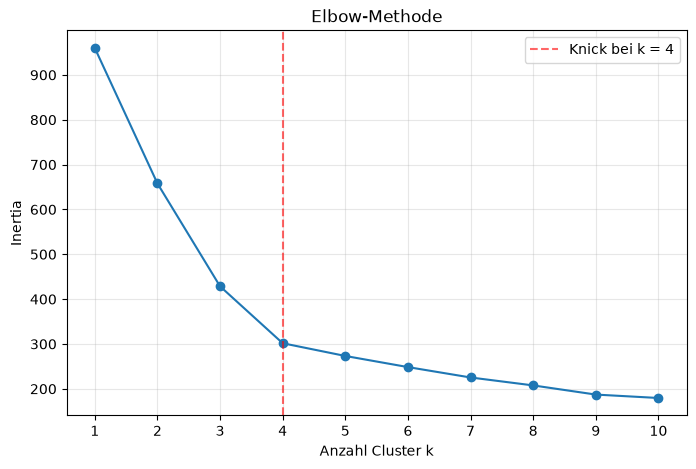

Verbesserung der Inertia pro zusätzlichem Cluster:
  von k=1 auf k=2:  302.0
  von k=2 auf k=3:  229.4
  von k=3 auf k=4:  126.9
  von k=4 auf k=5:   28.4
  von k=5 auf k=6:   24.8
  von k=6 auf k=7:   23.2
  von k=7 auf k=8:   17.7
  von k=8 auf k=9:   20.4
  von k=9 auf k=10:    7.6


In [15]:
# Schritt 3.5, Elbow-Kurve plotten
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.axvline(4, color='red', linestyle='--', alpha=0.6, label='Knick bei k = 4')
plt.xlabel('Anzahl Cluster k')
plt.ylabel('Inertia')
plt.title('Elbow-Methode')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Der Knick liegt klar bei k = 4. Man sieht es auch an den Verbesserungen pro Schritt:
print("Verbesserung der Inertia pro zusätzlichem Cluster:")
for k in range(1, 10):
    print(f"  von k={k} auf k={k+1}: {inertias[k-1] - inertias[k]:6.1f}")

In [17]:
# Schritt 4.6, Finales Modell mit k = 4 trainieren und die Cluster-Zuordnung anhängen
model = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = model.fit_predict(X_scaled)

print("Anzahl Kunden pro Cluster:")
print(df['cluster'].value_counts().sort_index())
df.head()

Anzahl Kunden pro Cluster:
cluster
0    40
1    40
2    40
3    40
Name: count, dtype: int64


,customer_id,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders,cluster
0,2001,14,430.54,32.18,13.4,1.5,0.51,2
1,2002,11,587.88,50.39,22.3,1.8,0.44,2
2,2003,2,532.52,254.72,0.4,2.6,0.17,0
3,2004,10,626.42,63.85,4.9,6.5,0.37,3
4,2005,2,128.21,64.15,3.9,0.2,0.24,1


In [18]:
# Schritt 4.7, Mittelwerte aller Features pro Cluster
profil = df.groupby('cluster').mean(numeric_only=True).drop(columns=['customer_id']).round(2)
profil

,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
cluster,,,,,,
0,3.52,1060.48,297.79,2.28,2.75,0.25
1,2.17,115.84,53.13,3.78,0.56,0.32
2,13.72,500.27,37.48,16.13,2.03,0.44
3,12.12,735.45,61.39,6.58,4.65,0.27


In [20]:
# Schritt 4.7, dieselbe Tabelle als z-Werte, damit man die Unterschiede besser sieht
z_profil = ((profil - X.mean()) / X.std()).round(2)
z_profil

,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
cluster,,,,,,
0,-0.79,1.06,1.64,-0.78,0.14,-0.50
1,-1.04,-1.13,-0.53,-0.54,-1.10,0.00
2,1.06,-0.24,-0.66,1.42,-0.26,0.85
3,0.77,0.31,-0.45,-0.10,1.22,-0.35


In [ ]:
# Schritt 4.8, den Clustern aussagekräftige Namen geben
namen = {
    0: 'Premiumkunden',
    1: 'Neukunden',
    2: 'Schnäppchenjäger',
    3: 'Treue Stammkunden'
}
df['segment'] = df['cluster'].map(namen)
profil_benannt = profil.copy()
profil_benannt.index = [namen[i] for i in profil_benannt.index]
profil_benannt

,total_orders,total_spent_chf,avg_order_value_chf,avg_discount_pct,loyalty_years,pct_weekend_orders
Premiumkunden,3.52,1060.48,297.79,2.28,2.75,0.25
Neukunden,2.17,115.84,53.13,3.78,0.56,0.32
Schnäppchenjäger,13.72,500.27,37.48,16.13,2.03,0.44
Treue Stammkunden,12.12,735.45,61.39,6.58,4.65,0.27


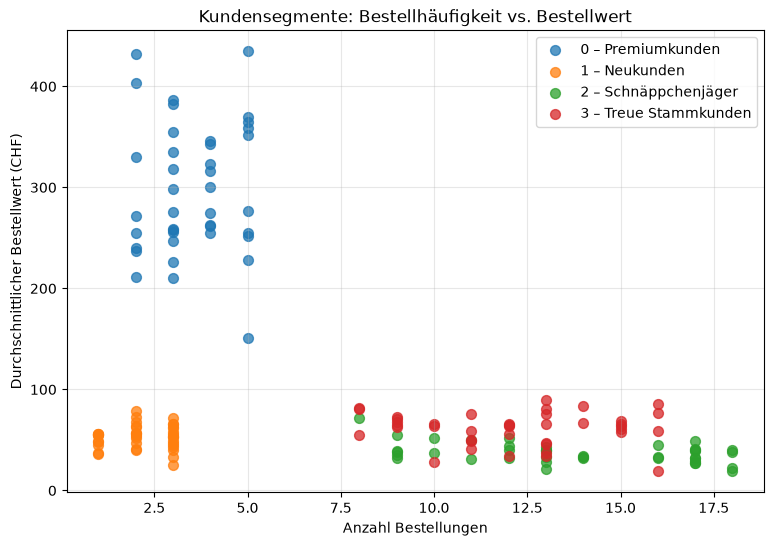

In [ ]:
# Schritt 5.9, Scatterplot total_orders vs. avg_order_value_chf, eingefärbt nach Cluster
plt.figure(figsize=(9, 6))
for c in sorted(df['cluster'].unique()):
    teil = df[df['cluster'] == c]
    plt.scatter(teil['total_orders'], teil['avg_order_value_chf'],
                label=f"{c} – {namen[c]}", alpha=0.75, s=50)
plt.xlabel('Anzahl Bestellungen')
plt.ylabel('Durchschnittlicher Bestellwert (CHF)')
plt.title('Kundensegmente: Bestellhäufigkeit vs. Bestellwert')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Die Premiumkunden und die Neukunden trennen sich sehr sichtbar.
# Schnäppchenjäger und Stammkunden liegen übereinander.

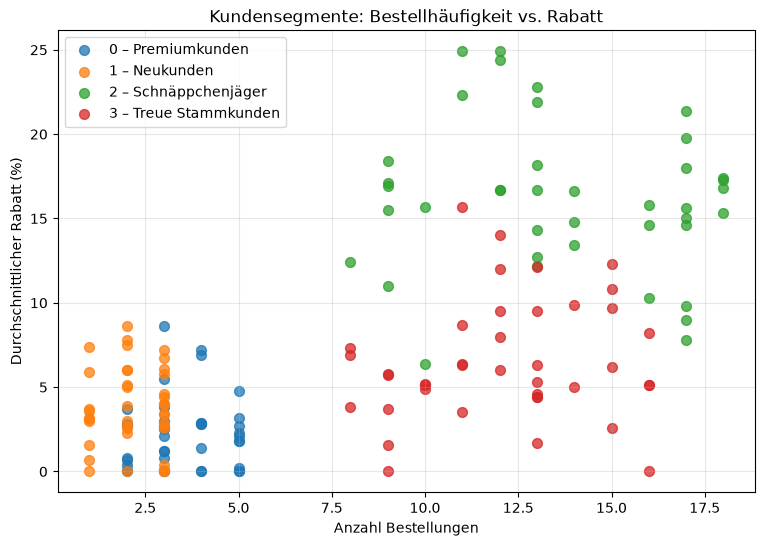

In [ ]:
# Schritt 5.9, zweiter Scatterplot mit dem Rabatt, um die restlichen zwei Cluster zu trennen
plt.figure(figsize=(9, 6))
for c in sorted(df['cluster'].unique()):
    teil = df[df['cluster'] == c]
    plt.scatter(teil['total_orders'], teil['avg_discount_pct'],
                label=f"{c} – {namen[c]}", alpha=0.75, s=50)
plt.xlabel('Anzahl Bestellungen')
plt.ylabel('Durchschnittlicher Rabatt (%)')
plt.title('Kundensegmente: Bestellhäufigkeit vs. Rabatt')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Jetzt hat es eine klare Trennung zwischen Schnäppchenjägern und Stammkunden, die man im ersten Scatterplot nicht gesehen hat